In [131]:
# https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

"""
Based on those two .CSV my idea is to create machine that detects whether news given are fake or true.

NOTE: becouse True.csv and Fake.csv files are very heavy please download it by yourself,
and put it into local files on colab. This way this program can work.

Much explanation will be provided underneath.
"""

In [132]:
import pandas as pd

dfT = pd.read_csv("True.csv")
dfF = pd.read_csv("Fake.csv")

dfT["Typ"] = 1   # prawdziwe
dfF["Typ"] = 0   # fałszywe

df = pd.concat([dfT, dfF], ignore_index=True)

df = df.dropna(subset=["text"])

In [133]:
pd.set_option('display.max_colwidth', None)

In [134]:
df.head(2)

title  \
0  As U.S. budget fight looms, Republicans flip their fiscal script   
1  U.S. military to accept transgender recruits on Monday: Pentagon   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [135]:
df[["Typ", "text"]].head(4)

Typ  \
0    1   
1    1   
2    1   
3    1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

In [136]:
import re

def czyszczenieTekstu(text):
    text = text.lower()                       # small letters
    text = re.sub(r"http\S+", " ", text)      # links
    text = re.sub(r"@\w+", " ", text)         # deletes @tags
    text = re.sub(r"[^a-z\s]", " ", text)     # numbers and special signs
    text = re.sub(r"\s+", " ", text).strip()  # white signs
    text = re.sub(r"\(.*?\)", " ", text)                     # (ACR), (Reuters), itp.
    text = re.sub(r"\[.*?\]", " ", text)                     # [youtube ...]
    text = re.sub(r"read more.*", " ", text)                  # trash at the end of articles
    text = re.sub(r"featured image.*", " ", text)             # trash at the end of articles
    text = re.sub(r"subscribe.*", " ", text)                  # trash at the end of articles
    text = re.sub(r"watch local news coverage.*", " ", text)  # trash at the end of articles
    return text

df["clean_text"] = df["text"].apply(czyszczenieTekstu)

In [137]:
df["clean_text"].head(2)

0    washington reuters the head of a conservative republican faction in the u s congress who voted this month for a huge expansion of the national debt to pay for tax cuts called himself a fiscal conservative on sunday and urged budget restraint in in keeping with a sharp pivot under way among republicans u s representative mark meadows speaking on cbs face the nation drew a hard line on federal spending which lawmakers are bracing to do battle over in january when they return from the holidays on wednesday lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues such as immigration policy even as the november congressional election campaigns approach in which republicans will seek to keep control of congress president donald trump and his republicans want a big budget increase in military spending while democrats also want proportional increases for non defense discretionary spending on programs that support education scientific research infrastructure public health and environmental protection the trump administration has already been willing to say we re going to increase non defense discretionary spending by about percent meadows chairman of the small but influential house freedom caucus said on the program now democrats are saying that s not enough we need to give the government a pay raise of to percent for a fiscal conservative i don t see where the rationale is eventually you run out of other people s money he said meadows was among republicans who voted in late december for their party s debt financed tax overhaul which is expected to balloon the federal budget deficit and add about trillion over years to the trillion national debt it s interesting to hear mark talk about fiscal responsibility democratic u s representative joseph crowley said on cbs crowley said the republican tax bill would require the united states to borrow trillion to be paid off by future generations to finance tax cuts for corporations and the rich this is one of the least fiscally responsible bills we ve ever seen passed in the history of the house of representatives i think we re going to be paying for this for many many years to come crowley said republicans insist the tax package the biggest u s tax overhaul in more than years will boost the economy and job growth house speaker paul ryan who also supported the tax bill recently went further than meadows making clear in a radio interview that welfare or entitlement reform as the party often calls it would be a top republican priority in in republican parlance entitlement programs mean food stamps housing assistance medicare and medicaid health insurance for the elderly poor and disabled as well as other programs created by washington to assist the needy democrats seized on ryan s early december remarks saying they showed republicans would try to pay for their tax overhaul by seeking spending cuts for social programs but the goals of house republicans may have to take a back seat to the senate where the votes of some democrats will be needed to approve a budget and prevent a government shutdown democrats will use their leverage in the senate which republicans narrowly control to defend both discretionary non defense programs and social spending while tackling the issue of the dreamers people brought illegally to the country as children trump in september put a march expiration date on the deferred action for childhood arrivals or daca program which protects the young immigrants from deportation and provides them with work permits the president has said in recent twitter messages he wants funding for his proposed mexican border wall and other immigration law changes in exchange for agreeing to help the dreamers representative debbie dingell told cbs she did not favor linking that issue to other policy objectives such as wall funding we need to do daca clean she said on wednesday trump aides will meet with congressional leaders to discuss those issues 

In [138]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')                   # this removes words like: and, is, the
nltk.download('punkt_tab')

stopWords = set(stopwords.words('english'))

customStopWords = [
    "acr", "fjs", "henningsen", "finicum", "cdata", "hesher", "cking", "helton", "var",
    "gitmo", "behar", "src", "getelementsbytagname", "createelement", "insertbefore",
    "getelementbyid", "parentnode", "jssdk", "beyonc", "nyp", "nowicki", "wfb", "xfbml",
    "sdk", "gt", "nbk", "pee", "camerota", "couric", "hammonds", "cher", "dobbs", "watters",
    "spaulding", "zeifman", "olbermann", "whoopi", "pirro", "lavoy", "stelter", "wnd",
    "affleck", "eichenwald", "tripp", "politifact", "sabo", "snopes", "jonben", "kfnx",
    "schlussel", "yr", "loomer", "ayyadurai", "bonifield", "posnanski", "caplan", "irving",
    "somodevilla", "timberg", "atty", "uhl", "keurig", "blogspot", "spreaker", "letterman",
    "crowder", "caplan", "irving", "somodevilla", "timberg", "atty", "uhl", "keurig",
    "blogspot", "spreaker", "letterman", "crowder", "tantaros", "santilli", "tawhidi",
    "stachowiak", "mediaite", "reiner", "tsarnaev", "opd", "bess", "vitale", "bila",
    "duca", "propornot", "doocy", "wwp", "crowell", "harrelson", "gosnell", "mcenany",
    "mcaleer", "pilger", "babin", "ucsb", "mikerin", "ssy", "chisholm", "thedcnf",
    "langdon", "teigen", "bolduan", "youngblood", "wictor", "sexton", "corden", "bundys",
    "jaffy", "krauthammer", "guilfoyle", "susteren", "greta", "jays", "midler", "fyi",
    "donnie", "tch", "sheen", "flickr", "hamtramck", "sarsour", "hardwick", "gratz",
    "oregonian", "ritzheimer", "shakur",  "digenova", "yashar", "cj", "sheppard", "huffpost",
    "deblasio", "vonn", "turi", "chesimard", "steyn", "felarca", "soeiro", "halperin",
    "hagee"

]

stopWords.update(customStopWords)

"""
I tested running this code without updating stopWords (line above), and it gives pretty much the same resaults.
My explanation to this is that TF-IDF will give those words high values anyway, so LogisticRegression won't suffer from that.
This is still good and important for me to create this list of words, becouse now i know, that my machine didn't learn based on
junk-words, but rather on proper words only.
"""

def preprocesujTekst(text):
    tokens = word_tokenize(text)             # this works becouse of nltk.download('punkt')
    tokens = [word for word in tokens if word not in stopWords]
    return tokens

df["tokens"] = df["clean_text"].apply(preprocesujTekst)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [139]:
df["tokens"].head(2)

,tokens
0,"[washington, reuters, head, conservative, republican, faction, u, congress, voted, month, huge, expansion, national, debt, pay, tax, cuts, called, fiscal, conservative, sunday, urged, budget, restraint, keeping, sharp, pivot, way, among, republicans, u, representative, mark, meadows, speaking, cbs, face, nation, drew, hard, line, federal, spending, lawmakers, bracing, battle, january, return, holidays, wednesday, lawmakers, begin, trying, pass, federal, budget, fight, likely, linked, issues, immigration, policy, even, november, congressional, election, campaigns, approach, republicans, seek, keep, control, congress, president, donald, trump, republicans, want, big, budget, increase, military, spending, democrats, also, want, proportional, increases, non, defense, discretionary, spending, programs, support, education, scientific, research, infrastructure, public, health, ...]"
1,"[washington, reuters, transgender, people, allowed, first, time, enlist, u, military, starting, monday, ordered, federal, courts, pentagon, said, friday, president, donald, trump, administration, decided, appeal, rulings, blocked, transgender, ban, two, federal, appeals, courts, one, washington, one, virginia, last, week, rejected, administration, request, put, hold, orders, lower, court, judges, requiring, military, begin, accepting, transgender, recruits, jan, justice, department, official, said, administration, challenge, rulings, department, defense, announced, releasing, independent, study, issues, coming, weeks, rather, litigate, interim, appeal, occurs, administration, decided, wait, dod, study, continue, defend, president, lawful, authority, district, court, meantime, official, said, speaking, condition, anonymity, september, pentagon, said, created, panel, senior, officials, ...]"


In [140]:
fakeTokens = df[df["Typ"] == 0]["tokens"]
trueTokens = df[df["Typ"] == 1]["tokens"]

from itertools import chain

fakeSłowa = list(chain.from_iterable(fakeTokens))
trueSłowa = list(chain.from_iterable(trueTokens))

from collections import Counter

fakeCzęstotliwość = Counter(fakeSłowa)
trueCzęstotliwość = Counter(trueSłowa)
fakeUnikalne = set(fakeCzęstotliwość.keys()) - set(trueCzęstotliwość.keys())

topFakeUnikalne = Counter({word: fakeCzęstotliwość[word] for word in fakeUnikalne})
top30FakeUnikalne = topFakeUnikalne.most_common(30)

print(top30FakeUnikalne)

[('uninterruptible', 213), ('philosophers', 209), ('savants', 205), ('moralists', 205), ('rascals', 204), ('masochists', 204), ('evangelists', 204), ('spore', 203), ('whined', 186), ('neocon', 159), ('blacklivesmatter', 158), ('pizzagate', 149), ('weasel', 144), ('hilariously', 138), ('barfly', 115), ('hissy', 112), ('rino', 112), ('neocons', 109), ('wannabe', 103), ('polictally', 101), ('zippers', 92), ('morons', 85), ('bullsh', 84), ('hmmm', 83), ('bilderberg', 81), ('gnashing', 80), ('grifters', 76), ('agitator', 74), ('buffoon', 73), ('gladio', 73)]


In [141]:
"""
acr = Alternate Current Radio Network (ACR)
filessupport = READ MORE RUSSIAGATE NEWS AT: 21st Century Wire RussiaGate FilesSUPPORT 21WIRE  SUBSCRIBE NOW & BECOME A MEMBER @21WIRE.TV",US_News,"December 14, 2017"
belowfeatured = Watch local news coverage of an interview featuring Benton below:[youtube https://www.youtube.com/watch?v=Gxj8O9sL_4Y&w=560&h=315]featured
flickr = 2016Featured image: Flickr/Flickr"

This are the examples of top used words. This ruins the idea and job I made, but I want to show you my work anyway.
My thinking process is that I made nice filtering, but data given to me contains too much junk that is hard to eliminate with regEx so we get words like "acr" or "belowfeatured"
The only way out that i see is to create customStopWords, and then update StopWords based on those customStopWords.
"""

'\nacr = Alternate Current Radio Network (ACR)\nfilessupport = READ MORE RUSSIAGATE NEWS AT: 21st Century Wire RussiaGate FilesSUPPORT 21WIRE  SUBSCRIBE NOW & BECOME A MEMBER @21WIRE.TV",US_News,"December 14, 2017"\nbelowfeatured = Watch local news coverage of an interview featuring Benton below:[youtube https://www.youtube.com/watch?v=Gxj8O9sL_4Y&w=560&h=315]featured \nflickr = 2016Featured image: Flickr/Flickr"\n\nThis are the examples of top used words. This ruins the idea and job I made, but I want to show you my work anyway.\nMy thinking process is that I made nice filtering, but data given to me contains too much junk that is hard to eliminate with regEx so we get words like "acr" or "belowfeatured"\nThe only way out that i see is to create customStopWords, and then update StopWords based on those customStopWords.\n'

In [142]:
"""
I need to add some more work on filtering words.

text = re.sub(r"\(.*?\)", " ", text)   # (ACR), (Reuters), itp.
text = re.sub(r"\[.*?\]", " ", text)   # [youtube ...]
text = re.sub(r"read more.*", " ", text)
text = re.sub(r"featured image.*", " ", text)
text = re.sub(r"subscribe.*", " ", text)
text = re.sub(r"watch local news coverage.*", " ", text)

after adding those i still have a lot of trash like:
fjs = data-mce-bogus=""1"">fjs</span></span>
henningsen = "Patrick Henningsen and Shawn Helton 21st Century WireOnce again
henningsen is news reporter i think

in this moment i asked GPT to create me regEx to eliminate this junk. I might use this commends:

    # 🔴 USUWANIE HTML TAGÓW
    text = re.sub(r"<.*?>", " ", text)

    # 🔴 USUWANIE encji typu &nbsp; &amp;
    text = re.sub(r"&\w+;", " ", text)

    # 🔴 USUWANIE rzeczy typu data-mce-bogus, src=, href=
    text = re.sub(r"\b\w*=\S+", " ", text)

    # 🔴 Usuwanie @username
    text = re.sub(r"@\w+", " ", text)

    # 🔴 Usuwanie URL
    text = re.sub(r"http\S+", " ", text)

    # 🔴 Usuwanie nawiasów z treścią
    text = re.sub(r"\(.*?\)", " ", text)
    text = re.sub(r"\[.*?\]", " ", text)

    # 🔴 ZAMIANA wszystkiego poza literami na spacje
    text = re.sub(r"[^a-z]", " ", text)

    # 🔴 Usuwanie pojedynczych liter i dziwnych tworów
    text = re.sub(r"\b[a-z]{1,2}\b", " ", text)

    # 🔴 Usuwanie nadmiaru spacji
    text = re.sub(r"\s+", " ", text).strip()

This might help me removing html stuff form text file.

"""

<>:4: SyntaxWarning: invalid escape sequence '\('
<>:4: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-1425774131.py:4: SyntaxWarning: invalid escape sequence '\('
  text = re.sub(r"\(.*?\)", " ", text)   # (ACR), (Reuters), itp.


'\nI need to add some more work on filtering words.\n\ntext = re.sub(r"\\(.*?\\)", " ", text)   # (ACR), (Reuters), itp.\ntext = re.sub(r"\\[.*?\\]", " ", text)   # [youtube ...]\ntext = re.sub(r"read more.*", " ", text)\ntext = re.sub(r"featured image.*", " ", text)\ntext = re.sub(r"subscribe.*", " ", text)\ntext = re.sub(r"watch local news coverage.*", " ", text)\n\nafter adding those i still have a lot of trash like: \nfjs = data-mce-bogus=""1"">fjs</span></span>\nhenningsen = "Patrick Henningsen and Shawn Helton 21st Century WireOnce again\nhenningsen is news reporter i think\n\nin this moment i asked GPT to create me regEx to eliminate this junk. I might use this commends:\n\n    # 🔴 USUWANIE HTML TAGÓW\n    text = re.sub(r"<.*?>", " ", text)\n\n    # 🔴 USUWANIE encji typu &nbsp; &amp;\n    text = re.sub(r"&\\w+;", " ", text)\n\n    # 🔴 USUWANIE rzeczy typu data-mce-bogus, src=, href=\n    text = re.sub(r"\x08\\w*=\\S+", " ", text)\n\n    # 🔴 Usuwanie @username\n    text = re.sub(

In [143]:
dfTopFake = pd.DataFrame(top30FakeUnikalne, columns=["word", "frequency"])
dfTopFake

,word,frequency
0,uninterruptible,213
1,philosophers,209
2,savants,205
3,moralists,205
4,rascals,204
5,masochists,204
6,evangelists,204
7,spore,203
8,whined,186
9,neocon,159


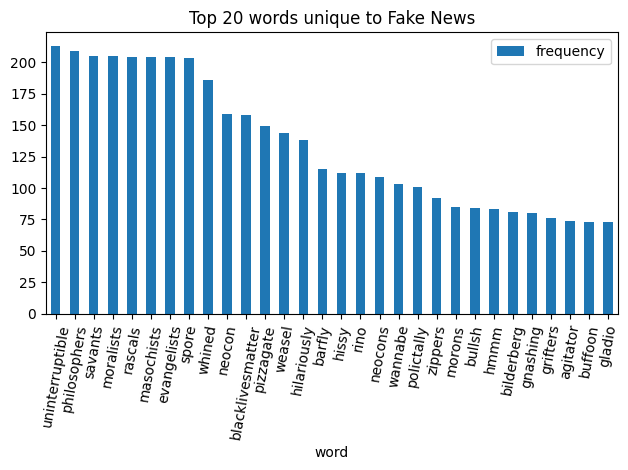

In [144]:
import matplotlib.pyplot as plt

dfTopFake.plot(kind="bar", x="word", y="frequency")
plt.title("Top 20 words unique to Fake News")
plt.xticks(rotation=80)
plt.tight_layout()

plt.show()

In [145]:
# Machine Learning:

from sklearn.model_selection import train_test_split #used to split train/test
from sklearn.feature_extraction.text import TfidfVectorizer #used for vectorizer
from sklearn.linear_model import LogisticRegression #machine learning
from sklearn.metrics import confusion_matrix, accuracy_score #summary that i use

X = df['clean_text']
y = df['Typ']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [146]:
vectorizer = TfidfVectorizer(
    stop_words = list(stopWords),
    max_features = 5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [147]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [148]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

confMatrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confMatrix)

Accuracy: 0.9867483296213808
Confusion Matrix:
 [[4621   75]
 [  44 4240]]


Extreamly good resaults. Machine learned words that makes news being fake. Accuracy: 98.7%

---

4621: True news correctly set as True

75: True news wrongly set as Fake (False Positive)

44: Fake news wrongly set as True (False Negative)

4240: Fake news correctly set as False
